# Cancer Detection using Custom CNN

**Project:** Deep Learning for Cancer Detection (Image-based)  
**Dataset:** Breast Histopathology Images (Kaggle)

---


## 1. Setup & Imports

In [1]:
!pip install -q kaggle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Download Dataset

In [2]:
# Breast Histopathology Images
!kaggle datasets download -d paultimothymooney/breast-histopathology-images
!unzip -q breast-histopathology-images.zip -d data/
print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images
License(s): CC0-1.0
100% 3.10G/3.10G [00:33<00:00, 99.2MB/s]

Download complete.


## 3. Create DataFrame

In [3]:
image_paths = []
labels = []

for root, dirs, files in os.walk("data"):
    for file in files:
        if file.endswith((".png", ".jpg", ".jpeg")):
            path = os.path.join(root, file)
            label = int(os.path.basename(os.path.dirname(path)))
            image_paths.append(path)
            labels.append(label)

df = pd.DataFrame({"image_path": image_paths, "label": labels})
print("Total images:", len(df))
print(df["label"].value_counts())
df.head()

Total images: 555048
label
0    397476
1    157572
Name: count, dtype: int64


,image_path,label
0,data/8959/1/8959_idx5_x1251_y351_class1.png,1
1,data/8959/1/8959_idx5_x651_y301_class1.png,1
2,data/8959/1/8959_idx5_x1351_y1151_class1.png,1
3,data/8959/1/8959_idx5_x1151_y201_class1.png,1
4,data/8959/1/8959_idx5_x1151_y301_class1.png,1


## 4. EDA

In [4]:
# Basic dataset information
print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nLabel percentage:")
print(df["label"].value_counts(normalize=True).round(4) * 100)

Dataset shape: (555048, 2)

Label distribution:
label
0    397476
1    157572
Name: count, dtype: int64

Label percentage:
label
0    71.61
1    28.39
Name: proportion, dtype: float64


In [25]:
df.head(10)

,image_path,label
0,data/8959/1/8959_idx5_x1251_y351_class1.png,1
1,data/8959/1/8959_idx5_x651_y301_class1.png,1
2,data/8959/1/8959_idx5_x1351_y1151_class1.png,1
3,data/8959/1/8959_idx5_x1151_y201_class1.png,1
4,data/8959/1/8959_idx5_x1151_y301_class1.png,1
5,data/8959/1/8959_idx5_x1201_y1251_class1.png,1
6,data/8959/1/8959_idx5_x1451_y2251_class1.png,1
7,data/8959/1/8959_idx5_x851_y401_class1.png,1
8,data/8959/1/8959_idx5_x1551_y1151_class1.png,1
9,data/8959/1/8959_idx5_x1501_y1201_class1.png,1


/tmp/ipykernel_2772/187092226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="Set2")


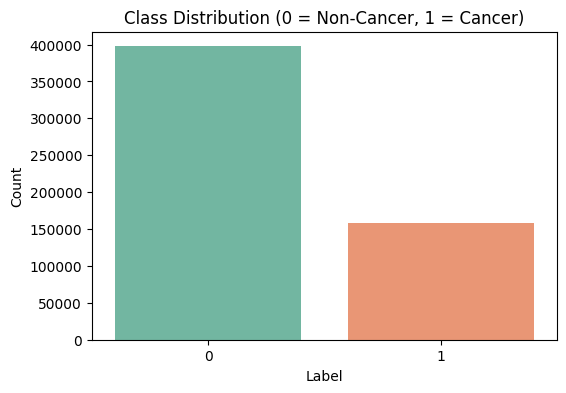

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df, palette="Set2")
plt.title("Class Distribution (0 = Non-Cancer, 1 = Cancer)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

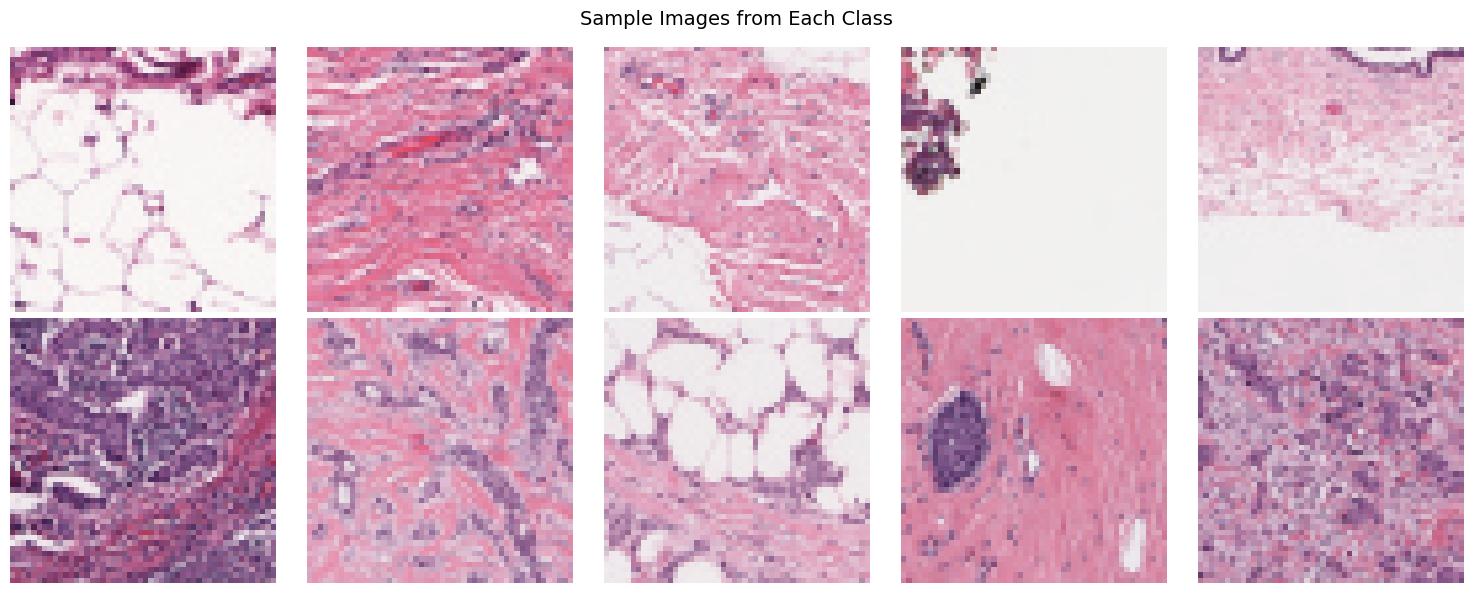

In [6]:
# Show sample images from both classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, label in enumerate([0, 1]):
    sample_paths = df[df["label"] == label]["image_path"].sample(5, random_state=42).values
    for j, path in enumerate(sample_paths):
        img = Image.open(path).convert("RGB")
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel("Non-Cancer" if label == 0 else "Cancer", fontsize=12)

plt.suptitle("Sample Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Check number of channels
sample_img = Image.open(df["image_path"].iloc[0])
print("Image mode:", sample_img.mode)          # Should be RGB
print("Image size:", sample_img.size)
print("Number of channels:", len(sample_img.getbands()))  # Should be 3

Image mode: RGB
Image size: (50, 50)
Number of channels: 3


Width  - Min: 50, Max: 50, Mean: 50.0
Height - Min: 50, Max: 50, Mean: 50.0


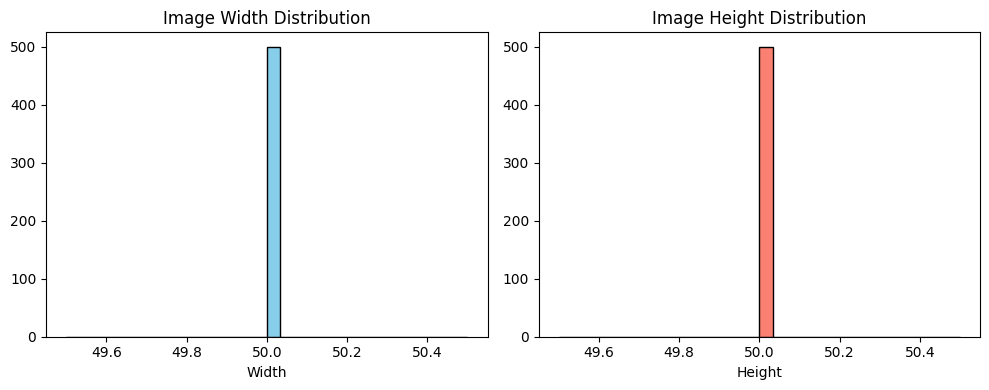

In [7]:
# Check image dimensions
widths, heights = [], []

for path in df["image_path"].sample(min(500, len(df)), random_state=42):
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.1f}")
print(f"Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=30, color="skyblue", edgecolor="black")
plt.title("Image Width Distribution")
plt.xlabel("Width")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, color="salmon", edgecolor="black")
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.tight_layout()
plt.show()

In [8]:
# Quick check for unreadable images
bad_images = []
for path in tqdm(df["image_path"].sample(min(1000, len(df)), random_state=42)):
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(path)

print(f"Corrupted images found: {len(bad_images)}")
if bad_images:
    print(bad_images[:5])

  0%|          | 0/1000 [00:00<?, ?it/s]

Corrupted images found: 0


## 5. Train / Validation / Test Split

In [9]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 388533 | Val: 83257 | Test: 83258


## 6. Dataset Class

In [10]:
class CancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

## 7. Transforms & DataLoaders

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(CancerDataset(train_df, train_transform), batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(CancerDataset(val_df, val_test_transform), batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(CancerDataset(test_df, val_test_transform), batch_size=32, shuffle=False, num_workers=2)

print("DataLoaders ready.")

DataLoaders ready.


## 8. Custom CNN Model

In [11]:
class CancerCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CancerCNN().to(device)

# ---------- Handle Class Imbalance ----------
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
# --------------------------------------------

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

Class weights: tensor([0.6982, 1.7613], device='cuda:0')


## 9. Training Functions

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

## 10. Training Loop

In [16]:
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)
best_acc = 0

for epoch in range(1, 5):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_cancer_cnn.pth")
        print("  → Best model saved")

print("\nTraining finished. Best Val Acc:", round(best_acc, 4))

  0%|          | 0/12142 [00:00<?, ?it/s]

  0%|          | 0/2602 [00:00<?, ?it/s]

Epoch 01 | Train Acc: 0.8365 | Val Acc: 0.8082
  → Best model saved


  0%|          | 0/12142 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240><function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240><function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240><function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240>


Traceback (most recent call last):
Traceback (most recent call last):

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    
self._shutdown_workers()  File "/usr/local/lib/pyth

...

Epoch 03 | Train Acc: 0.8594 | Val Acc: 0.8527
  → Best model saved


  0%|          | 0/12142 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

    Traceback (most recent call last):
if w.is_alive():
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
      File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()    
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'    
AssertionErrorif w.is_alive():: 
  File "/usr/lib/python3.13/multiprocessing/pro

  0%|          | 0/2602 [00:00<?, ?it/s]

Epoch 04 | Train Acc: 0.8636 | Val Acc: 0.8755
  → Best model saved

Training finished. Best Val Acc: 0.8755


## 11. Final Evaluation on Test Set

  0%|          | 0/2602 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b56ddb47240>Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():if w.is_alive():

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a


Classification Report:
              precision    recall  f1-score   support

  Non-Cancer       0.95      0.87      0.91     59622
      Cancer       0.73      0.88      0.80     23636

    accuracy                           0.87     83258
   macro avg       0.84      0.88      0.85     83258
weighted avg       0.89      0.87      0.88     83258

ROC-AUC Score: 0.9469839425113137


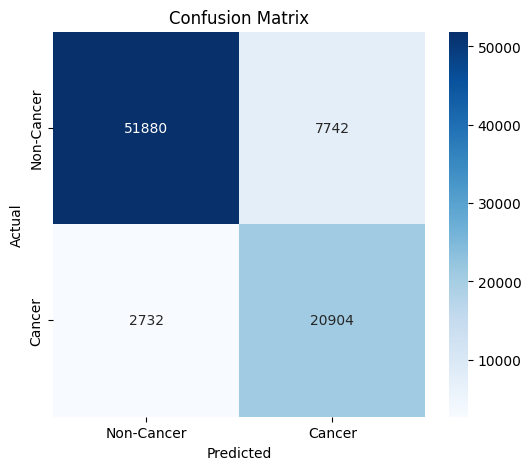

In [17]:
model.load_state_dict(torch.load("best_cancer_cnn.pth"))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Non-Cancer", "Cancer"]))

print("ROC-AUC Score:", roc_auc_score(all_labels, all_probs))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Cancer", "Cancer"],
            yticklabels=["Non-Cancer", "Cancer"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

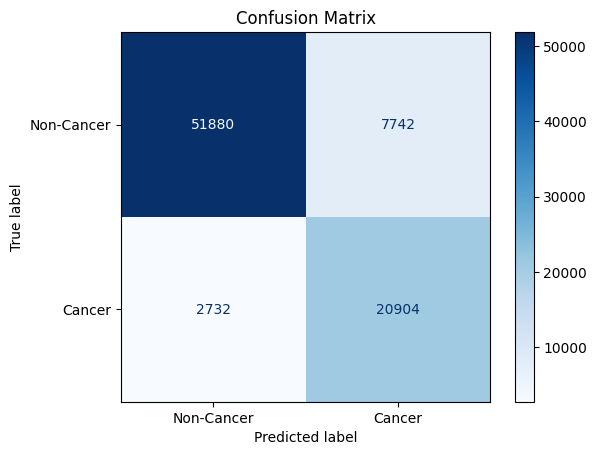

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Non-Cancer", "Cancer"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

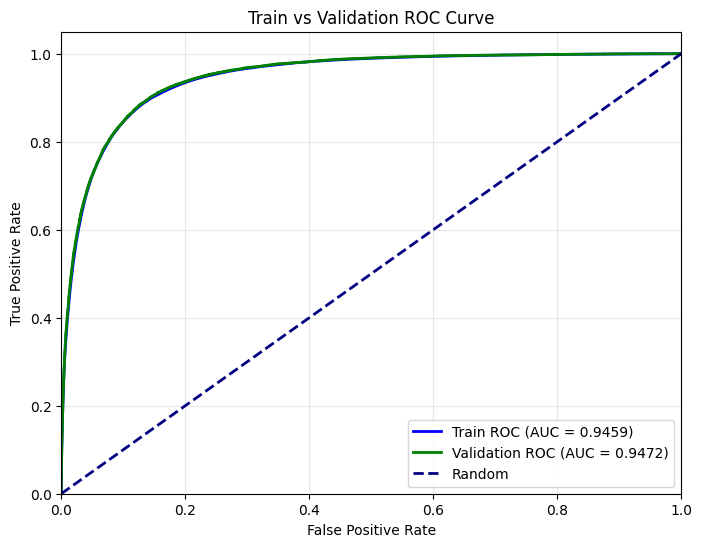

Training Accuracy   : 0.8772
Validation Accuracy : 0.8755
Train AUC           : 0.9459
Validation AUC      : 0.9472


In [23]:
from sklearn.metrics import roc_curve, auc, accuracy_score

def get_roc_and_acc(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    accuracy = accuracy_score(all_labels, all_preds)

    return fpr, tpr, roc_auc, accuracy


# Get data for Train and Validation
fpr_train, tpr_train, auc_train, acc_train = get_roc_and_acc(model, train_loader, device)
fpr_val, tpr_val, auc_val, acc_val = get_roc_and_acc(model, val_loader, device)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color="blue", lw=2, label=f"Train ROC (AUC = {auc_train:.4f})")
plt.plot(fpr_val, tpr_val, color="green", lw=2, label=f"Validation ROC (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Validation ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print Accuracy + AUC
print(f"Training Accuracy   : {acc_train:.4f}")
print(f"Validation Accuracy : {acc_val:.4f}")
print(f"Train AUC           : {auc_train:.4f}")
print(f"Validation AUC      : {auc_val:.4f}")


Saving 10262_idx5_x1001_y2001_class0.png to 10262_idx5_x1001_y2001_class0.png


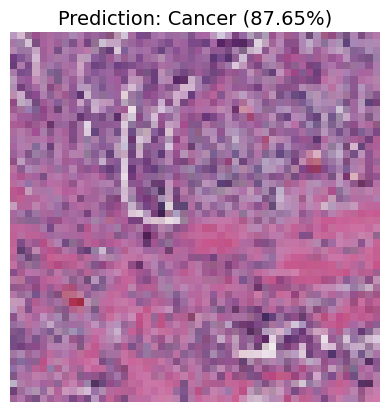

Prediction : Cancer
Confidence : 87.65%
Non-Cancer Probability: 12.35%
Cancer Probability    : 87.65%


In [31]:
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Load model (already in /content/)
model = CancerCNN().to(device)
model.load_state_dict(torch.load("/content/best_cancer_cnn.pth", map_location=device))
model.eval()

# Transform
predict_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Upload a test image
uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename).convert("RGB")
    img_tensor = predict_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_class = torch.argmax(probs).item()
        confidence = probs[pred_class].item()

    label = "Cancer" if pred_class == 1 else "Non-Cancer"

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence*100:.2f}%)", fontsize=14)
    plt.show()

    print(f"Prediction : {label}")
    print(f"Confidence : {confidence*100:.2f}%")
    print(f"Non-Cancer Probability: {probs[0]*100:.2f}%")
    print(f"Cancer Probability    : {probs[1]*100:.2f}%")